# Librerías y configuraciones

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.decomposition import IncrementalPCA
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import random

In [2]:
# ---------- CONFIG ----------

CSV_PATH  = 'embeddings/pd.csv'          
# el CSV con PATNO y MBRS (etiquetas de cada paciente)

TEXT_DIR  = 'embeddings/text_embeddings_PD'  
# carpeta con los 1560 .npy de ClinicalBERT (768d cada uno)

IMG_DIR   = 'embeddings/head_01'             
# carpeta con los 399 .npy de SAMMed3D (12,12,64 cada uno)

OUTPUT_CSV = 'embeddings/labels_filtered.csv'
# CSV que vamos a generar con solo los 212 pacientes válidos y su clase

PCA_PATH = 'embeddings/img_pca.joblib'
# ruta donde guardamos el PCA ajustado a las imágenes (para luego usarlo en el Dataset)

PCA_N_COMPONENTS = 1024
# número de componentes a los que reducimos las imágenes con PCA

PROJ_DIM  = 256   
# dimensión a la que proyectamos AMBAS modalidades antes de fusionar
# 256 es un valor estándar, ni muy grande ni muy pequeño

BATCH_SIZE = 8    
# cuántos pacientes procesa el modelo a la vez
# 8 porque tenemos pocos datos (212), no necesitamos más

EPOCHS = 30       
# cuántas veces el modelo ve todos los datos durante entrenamiento

LR = 1e-4         
# learning rate: 0.0001

NUM_CLASSES = 2   
# Leve y Moderado

RANDOM_SEED = 42  
# randomico para reproducibilidad

TEMPERATURE = 0.07

Esta función garantiza que cada vez que corramos el notebook obtengamos los mismos resultados, misma división train/test, mismos pesos iniciales, todo igual.

In [3]:
def seed_all(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_all()

# Información de los embeddings

<h3>Embeddings mri </h3>

In [4]:
ruta_mri = "embeddings/mri_embeddings"  # carpeta donde están los archivos .npy
archivo = os.listdir(ruta_mri)[0]  # toma el primero que encuentre
arr = np.load(os.path.join(ruta_mri, archivo), mmap_mode='r')

print("archivo:", archivo)
print("shape:", arr.shape)
print("dtype:", arr.dtype)

archivo: 3854.npy
shape: (2, 48, 32, 32, 32)
dtype: float16


In [7]:
ruta_mri = "embeddings/head_01"  # carpeta donde están los archivos .npy
archivo = os.listdir(ruta_mri)[0]  # toma el primero que encuentre
arr = np.load(os.path.join(ruta_mri, archivo))

print("archivo:", archivo)
print("shape:", arr.shape)
print("dtype:", arr.dtype)

archivo: 3968.npy
shape: (12, 12, 64)
dtype: float16


In [8]:
ruta_mri = "embeddings/head_01"  # carpeta donde están los archivos .npy
archivo = os.listdir(ruta_mri)[0]  # toma el primero que encuentre
arr = np.load(os.path.join(ruta_mri, archivo))

print("archivo:", archivo)
print("shape:", arr.shape)
print("dtype:", arr.dtype)

archivo: 3968.npy
shape: (12, 12, 64)
dtype: float16


el shape se basa en <br>
12,12 -> ejes espaciales X y Y <br>
64 -> Las caracteristicas aprendidas por SAMMed3D <br>

<h3>Embeddings textual </h3>

In [6]:
ruta_txt = "embeddings/text_embeddings_PD"
archivo_txt = os.listdir(ruta_txt)[0]
arr_txt = np.load(os.path.join(ruta_txt, archivo_txt))

print("archivo:", archivo_txt)
print("shape:", arr_txt.shape)
print("dtype:", arr_txt.dtype)

archivo: 73887.npy
shape: (768,)
dtype: float32


In [7]:
ids_mri = set(f.replace(".npy", "") for f in os.listdir(ruta_mri) if f.endswith(".npy"))
ids_txt = set(f.replace(".npy", "") for f in os.listdir(ruta_txt) if f.endswith(".npy"))

interseccion = ids_mri & ids_txt

print(f"Pacientes con MRI:           {len(ids_mri)}")
print(f"Pacientes con texto clínico: {len(ids_txt)}")
print(f"Pacientes con AMBOS:         {len(interseccion)}")

Pacientes con MRI:           259
Pacientes con texto clínico: 1560
Pacientes con AMBOS:         190


# **Creación csv de clasificación de parkinson**

<h4> Busqueda de qué pacientes tienen ambos archivos .npy y guardar un CSV limpio con sus etiquetas de clasificacion MBRS.

In [7]:
# Load CSV and filter IDs by .npy presence
print('Loading CSV and filtering IDs...')

# verificar que el CSV existe
if not os.path.exists(CSV_PATH):
  raise FileNotFoundError(f'CSV not found: {CSV_PATH}')

# cargar el CSV con todos los pacientes
df = pd.read_csv(CSV_PATH)

# buscar automáticamente la columna de ID y la columna MBRS
ID_COL = 'PATNO' if 'PATNO' in df.columns else ('ID' if 'ID' in df.columns else df.columns[0])
MBRS_COL = 'MBRS' if 'MBRS' in df.columns else ('MBRS' if 'MBRS' in df.columns else None)
if MBRS_COL is None:
  raise ValueError('Cannot find a Hoehn&Yahr column (MBRS or MBRS). Update MBRS_COL variable')

# quedarse solo con ID y MBRS
df = df[[ID_COL, MBRS_COL]].copy()

# convertir ID a string para coincidir con nombres de archivos .npy
df[ID_COL] = df[ID_COL].astype(str)

# asegurar que MBRS sea numérico y eliminar filas sin etiqueta
df[MBRS_COL] = pd.to_numeric(df[MBRS_COL], errors='coerce')
df = df.dropna(subset=[MBRS_COL])

# mapear MBRS a 3 clases:
# 0-7   = clase 0 (leve)
# 8-15  = clase 1 (moderado)
# 16+   = clase 2 (severo)
def map_mbrs_to_3(x):
    if 0 <= x <= 7:
        return 0
    elif 8 <= x <= 15:
        return 1
    else:
        return 2

df['MBRS_COL'] = df[MBRS_COL].apply(map_mbrs_to_3)
print(df)

# listar .npy disponibles en cada carpeta
text_files = [f for f in os.listdir(TEXT_DIR) if f.endswith('.npy')]
img_files  = [f for f in os.listdir(IMG_DIR)  if f.endswith('.npy')]

# extraer IDs de los nombres de archivo
text_ids = set([os.path.splitext(f)[0] for f in text_files])
img_ids  = set([os.path.splitext(f)[0] for f in img_files])

# solo pacientes con AMBOS archivos
valid_ids = sorted(list(text_ids.intersection(img_ids)))
print(f'Found {len(text_ids)} text .npy, {len(img_ids)} img .npy, intersection {len(valid_ids)}')

# filtrar a los 212 pacientes válidos
df = df[df[ID_COL].isin(valid_ids)].copy()
print('After filtering CSV by available npys:', len(df))

# guardar CSV limpio con columnas: id y MBRS_COL
out_df = df.rename(columns={ID_COL:'id', MBRS_COL:'MBRS'})[['id','MBRS_COL']]
out_df.to_csv(OUTPUT_CSV, index=False)
print('Saved filtered CSV:', OUTPUT_CSV)

Loading CSV and filtering IDs...
       PATNO  MBRS  MBRS_COL
0       3001  13.0         1
1       3002  14.0         1
2       3003   8.0         1
3       3005   0.0         0
4       3006  14.0         1
...      ...   ...       ...
1555  476236   3.0         0
1556  492876   6.0         0
1557  496671   1.0         0
1558  504436   4.0         0
1559  522583   2.0         0

[1560 rows x 3 columns]
Found 1560 text .npy, 399 img .npy, intersection 212
After filtering CSV by available npys: 212
Saved filtered CSV: embeddings/labels_filtered.csv


Esto genera un csv con el id del paciente y la clasificacion de MBRS <br>
 0-7   = clase 0 (leve) <br>
 8-15  = clase 1 (moderado) <br>
 16+   = clase 2 (severo) <br>

# **Reducción de dimensionalidad PCA**

<h4> Miramos que todos los archivos de las MRI tengan la misma dimensionalidad

In [8]:
# ----------------------------------------------------
# Filtrar archivos .npy que NO tengan shape (12, 12, 64)
# ----------------------------------------------------
valid_ids = []
bad_ids = []

for f in os.listdir(IMG_DIR):
    if not f.endswith(".npy"):
        continue
    id_ = os.path.splitext(f)[0]
    arr = np.load(os.path.join(IMG_DIR, f))
    if arr.ndim == 3 and arr.shape[0] == 12:
        valid_ids.append(id_)
    else:
        bad_ids.append(id_)

print("IDs válidos:", len(valid_ids))
print("IDs eliminados:", len(bad_ids))
print("Ejemplo de eliminados:", bad_ids[:10])

# Filtrar el dataframe original
df = df[df[ID_COL].isin(valid_ids)].reset_index(drop=True)
print("Sujetos finales después del filtrado:", len(df))

IDs válidos: 399
IDs eliminados: 0
Ejemplo de eliminados: []
Sujetos finales después del filtrado: 212


<h4>Como el tamaño originalmente era (2,48,32,32,32) se hace una reducción de dimensionalidad porque (2,48,32,32,32) = 3,145,728 <br>
son demasiadas caracteristicas y no es manejable por eso se reduce a: (12, 12, 64) = 9,216

In [ ]:
# @title PCA para imágenes: generar memmaps y ajustar PCA
# ---------- CONFIG ----------
# PCA_N_COMPONENTS = 1024 # reduce flattened vector to this size (tuneable)
# --------------------------
PCA_N_COMPONENTS = min(PCA_N_COMPONENTS, len(valid_ids))
# ---------- 2) Fit IncrementalPCA on flattened image embeddings (if PCA not exists) ----------
# PCA is important because flattened vectors are huge; we reduce to PCA_N_COMPONENTS
import os
import numpy as np
import joblib
from sklearn.decomposition import IncrementalPCA
import torch
import torch.nn.functional as F

os.makedirs(FLAT_DIR, exist_ok=True)
DOWNSAMPLE_SIZE = (16, 16, 16)
# ======================================


# --------------------------
# Función para downsamplear un embedding 3D pesado
# --------------------------
def downsample_3d(arr):
    # arr viene como (2, D, H, W)

    # si tiene 5 dimensiones, combina los 2 volúmenes
    if arr.ndim == 5 and arr.shape[0] == 2:
        arr = arr.mean(axis=0)   # ---> (48,32,32,32)

    # si aún tiene 4 dimensiones, eliminar ejes extra si son 1 o canal
    if arr.ndim == 4:
        # caso típico (D,H,W,C) o (C,D,H,W)
        if arr.shape[0] not in [32,48]:  # entonces es canal
            arr = arr[0]
        else:
            arr = arr[...,0]  # último canal

    # ahora debe ser 3D
    if arr.ndim != 3:
        raise ValueError(f"Se esperaba un 3D, llegó: {arr.shape}")

    # downsample con PyTorch
    t = torch.from_numpy(arr).float().unsqueeze(0).unsqueeze(0)  # (1,1,D,H,W)
    t_ds = F.interpolate(t, size=(16,16,16), mode="trilinear", align_corners=False)
    return t_ds.squeeze().numpy()


# ============================================================
#          1) GENERAR ARCHIVOS MEMMAP (uno por ID)
# ============================================================
print("=== Paso 1/3: Generando memmaps downsampleados ===")

for id_ in valid_ids:
    npy_path = os.path.join(IMG_DIR, id_ + ".npy")
    if not os.path.exists(npy_path):
        print("No existe:", npy_path)
        continue

    # cargar sin ocupar RAM
    arr = np.load(npy_path, mmap_mode="r")
    flat = downsample_3d(arr)

    mm_path = os.path.join(FLAT_DIR, id_ + ".dat")

    # guardar como memmap
    fp = np.memmap(mm_path, dtype="float32", mode="w+", shape=flat.shape)
    fp[:] = flat[:]
    del fp  # liberar
print("Listo memmaps.")


# ============================================================
#           2) AJUSTAR INCREMENTAL PCA SOBRE MEMMAPS
# ============================================================
# if os.path.exists(PCA_PATH):
#     print("Cargando PCA existente:", PCA_PATH)
#     pca = joblib.load(PCA_PATH)
# else:
print("=== Paso 2/3: Entrenando IncrementalPCA ===")

pca = IncrementalPCA(n_components=PCA_N_COMPONENTS)
files = sorted(os.listdir(FLAT_DIR))
batch_size = 1024   # pequeño = no explota Colab

for i in range(0, len(files), batch_size):
    batch_files = files[i:i+batch_size]
    mats = []

    for f in batch_files:
        fp = np.memmap(os.path.join(FLAT_DIR, f), dtype="float32", mode="r")
        mats.append(np.array(fp))

    X = np.stack(mats)
    pca.partial_fit(X)

    print(f"PCA parcial: {i+len(batch_files)}/{len(files)}")

joblib.dump(pca, PCA_PATH)
print("PCA guardado en", PCA_PATH)


# ============================================================
#      3) Función para transformar un embedding con PCA
# ============================================================
def img_flatten_and_pca(path, pca_obj):
    arr = np.load(path, mmap_mode="r")
    flat = downsample_3d(arr)
    vec = pca_obj.transform(flat.reshape(1, -1))
    return vec.ravel().astype("float32")


print("=== PCA LISTO ===")

con los datos que se tienen solo se pueden hacer estos pasos:

Modelo para aprender a reducir las imagenes a 212 <br>

El modelo se pregunta ¿cuáles de estos 9,216 números de cada embedding del paciente cambian más entre pacientes? <br>
- Los que casi no cambian entre pacientes no aportan información útil — los elimina. Los que sí cambian mucho los conserva.
- Al final se queda con los 212 números más informativos


In [9]:
# aplanar y ajustar PCA directamente sobre los .npy
# saldrá 399 el tamaño porque hay 399 mris
pca = IncrementalPCA(n_components=min(PCA_N_COMPONENTS, len(valid_ids)))

X = np.stack([
    np.load(os.path.join(IMG_DIR, id_ + ".npy")).astype("float32").flatten()
    for id_ in valid_ids
])

pca.fit(X)
joblib.dump(pca, PCA_PATH)
print("PCA guardado en", PCA_PATH)

PCA guardado en embeddings/img_pca.joblib


<h4> Separamos los severos del resto porque solo se entrena con  leve y moderado

In [10]:
# los severos van aparte - solo para inferencia (no entrenamiento)
inference_df = out_df[out_df["MBRS_COL"] == 2]

# leve y moderado - estos se usan para entrenar
out_df = out_df[out_df["MBRS_COL"] != 2]

print(out_df)
print(inference_df)

          id  MBRS_COL
4       3006         1
16      3027         0
23      3059         0
27      3066         0
31      3077         1
...      ...       ...
1464  296083         0
1474  302526         1
1476  302575         0
1507  318884         0
1510  319735         0

[205 rows x 2 columns]
          id  MBRS_COL
77      3180         2
206     3461         2
295     3664         2
535    40731         2
1196  194971         2
1213  211045         2
1358  250149         2


<h4>Balance entre clases

In [11]:
print(out_df["MBRS_COL"].value_counts().sort_index())

MBRS_COL
0    141
1     64
Name: count, dtype: int64


<h4> Guardamos el csv con los de clase 0 y 1

In [12]:
out_df.to_csv("mri_ids.csv", index=False)

# **Entrenamiento multimodal**

Preparación de los datos para que se puedan consumir
-  Definir cómo cargar un paciente (PDFlattenedDataset)
-  Dividir los paciente en entrenamiento / validación / test
-  Convertimos en tensores lo datos
-  Los datos se dividen en batch de 8 con (Dataloader)

In [13]:
class PDFlattenedDataset(Dataset):
  
  def __init__(self, csv_path, text_dir, img_dir, pca_obj=None):

    # carga el CSV con los IDs y etiquetas
    self.df = pd.read_csv(csv_path)

    # carpeta con los embeddings de texto clínico
    self.text_dir = text_dir

    # carpeta con los embeddings de imagen MRI
    # Aquí antes era flat_dir .dat, ahora es img_dir .npy
    self.img_dir = img_dir

    # modelo PCA para reducir la imagen de 9,216 a 212 componentes
    self.pca = pca_obj

  def __len__(self):
    # retorna cuántos pacientes tiene el dataset
    return len(self.df)

  def __getitem__(self, idx):
    # obtiene la fila del paciente en la posición idx
    row = self.df.iloc[idx]
    id_ = str(row['id'])
    MBRS = int(row['MBRS_COL'])

    # carga el embedding de texto clínico (768 números)
    text_emb = np.load(os.path.join(self.text_dir, id_ + '.npy')).astype(np.float32)

    # Cambio que antes leía .dat con memmap, ahora carga .npy directamente
    arr = np.load(os.path.join(self.img_dir, id_ + '.npy')).astype(np.float32)

    # aplana (12,12,64) -> 9,216 y aplica PCA -> 212 componentes
    img_vec = self.pca.transform(arr.flatten().reshape(1, -1)).ravel()

    # convierte a tensores de PyTorch
    txt_t = torch.tensor(text_emb, dtype=torch.float32)
    img_t = torch.tensor(img_vec,  dtype=torch.float32)
    label = torch.tensor(MBRS,     dtype=torch.long)

    return txt_t, img_t, label


# elimina pacientes con shape incorrecta (bad_ids del filtro anterior)
out_df = out_df[~out_df['id'].isin(bad_ids)].reset_index(drop=True)

# divide en train 70% / val 10% / test 20%
train_df, test_df = train_test_split(out_df, test_size=0.2,   stratify=out_df['MBRS_COL'],   random_state=RANDOM_SEED)
train_df, val_df  = train_test_split(train_df, test_size=0.125, stratify=train_df['MBRS_COL'], random_state=RANDOM_SEED)

# guarda los CSVs de cada split
train_csv = os.path.join(os.path.dirname(OUTPUT_CSV), 'train_labels.csv')
val_csv   = os.path.join(os.path.dirname(OUTPUT_CSV), 'val_labels.csv')
test_csv  = os.path.join(os.path.dirname(OUTPUT_CSV), 'test_labels.csv')
train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv,   index=False)
test_df.to_csv(test_csv,  index=False)
print('Split saved:', train_csv, val_csv, test_csv)

# crea los datasets usando los CSVs, las carpetas de embeddings y el PCA
# -> reemplazamos FLAT_DIR por IMG_DIR, eliminamos pca_obj innecesario de memmap
train_ds = PDFlattenedDataset(train_csv, TEXT_DIR, IMG_DIR, pca)
val_ds   = PDFlattenedDataset(val_csv,   TEXT_DIR, IMG_DIR, pca)
test_ds  = PDFlattenedDataset(test_csv,  TEXT_DIR, IMG_DIR, pca)

# crea los DataLoaders — entregan BATCH_SIZE=8 pacientes a la vez
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)   # aleatorio para entrenar
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)  # fijo para validar
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)  # fijo para testear

Split saved: embeddings/train_labels.csv embeddings/val_labels.csv embeddings/test_labels.csv


Comprobación de los split

In [14]:
# ver qué devuelve el dataset para el primer paciente
txt, img, label = train_ds[100]

print("texto shape:", txt.shape)
print("imagen shape:", img.shape)
print("etiqueta:", label)

texto shape: torch.Size([768])
imagen shape: torch.Size([399])
etiqueta: tensor(1)


<h4> Definición y creación del modelo

- Entra un batch de 8 pacientes: Texto (8,768) e imagen (8, 399)
- Se hace la proyección del texto e imagen a (8, 256)
- Se concatena los datos: (8, 256) + (8, 256) = (8, 512)
- Se realiza la clasificación: (8, 512) -> Linear -> ReLU -> Dropout -> Linear -> (8, 2)
- Salida: Por paciente ->  [0.8, 0.2] = leve
- Retornamos 3 cosas -> predicciones, texto proyectado, imagen proyectada

In [15]:
# Definición del modelo

class FusionFC(nn.Module):
    def __init__(self, text_dim, img_dim, proj_dim=PROJ_DIM, num_classes=NUM_CLASSES):
        super().__init__()

        # proyección del texto: 768 = 256
        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, proj_dim),  # reduce de 768 a 256
            nn.ReLU(),                       # elimina valores negativos
            nn.LayerNorm(proj_dim)           # normaliza para estabilizar entrenamiento
        )

        # proyección de la imagen: 399 = 256
        self.img_proj = nn.Sequential(
            nn.Linear(img_dim, proj_dim),   # reduce de 399 a 256
            nn.ReLU(),                       # elimina valores negativos
            nn.LayerNorm(proj_dim)           # normaliza para estabilizar entrenamiento
        )

        # clasificador: recibe texto(256) + imagen(256) = 512 - 2 clases
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim*2, 512),     # 512 - 512
            nn.ReLU(),                       # elimina valores negativos
            nn.Dropout(0.2),                 # apaga 20% de neuronas para evitar memorizar
            nn.Linear(512, num_classes)      # 512 - 2 (leve o moderado)
        )

    def forward(self, txt, img):
        # proyecta texto a 256
        zt = self.text_proj(txt)

        # proyecta imagen a 256
        zi = self.img_proj(img)

        # concatena ambas proyecciones → 512
        fused = torch.cat([zt, zi], dim=1)

        # clasifica y retorna predicción + proyecciones (para loss contrastiva)
        return self.classifier(fused), zt, zi

<h4> Obtener dimensiones reales para inicializar el modelo

In [16]:
# usar un ID que tenga tanto texto como imagen
sample_id = list(text_ids & img_ids)[0]

# carga un archivo de texto de ejemplo para saber su dimensión
sample_txt = np.load(os.path.join(TEXT_DIR, sample_id + '.npy')).astype(np.float32)

# carga un archivo de imagen de ejemplo
sample_img_flat = np.load(os.path.join(IMG_DIR, sample_id + '.npy'))

# si tiene un canal extra de tamaño 1, lo elimina
if sample_img_flat.ndim > 1 and sample_img_flat.shape[0] == 1:
    sample_img_flat = sample_img_flat[0]

# aplana la imagen (12,12,64) → 9,216
sample_img_flat = sample_img_flat.flatten().astype(np.float32)

# dimensión del texto → 768
text_dim = sample_txt.shape[0]

# dimensión de la imagen después del PCA → 399
img_dim = pca.n_components_ if hasattr(pca, 'n_components_') else PCA_N_COMPONENTS

print('text_dim', text_dim, 'img_dim (after PCA)', img_dim)

MRI_DIM   = img_dim
SPECT_DIM = MRI_DIM

text_dim 768 img_dim (after PCA) 399


<h4> Entrenamiento

Por cada epoca 30 veces:
- Toma 8 pacientes del train_loader
- El modelo predice leve/moderado
- Mide el error (loss)
- Ajusta los pesos

<h4>Constractive loss</h4> <br>

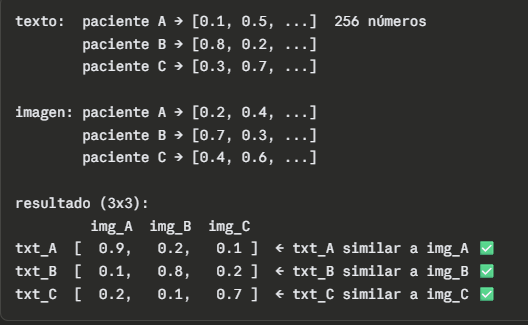

- / temperature — el 0.07 hace los valores más extremos, forzando al modelo a ser más seguro.
- labels = [0, 1, 2] — le dice que el texto del paciente A debe coincidir con la imagen A, B con B, C con C.
- loss_t + loss_i / 2 — penaliza en ambas direcciones

In [17]:
EPOCHS = 30

In [18]:
# usar GPU si está disponible, sino CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# crea el modelo con las dimensiones reales
model = FusionFC(text_dim=text_dim, img_dim=img_dim).to(device)

# Adam ajusta los pesos del modelo en cada paso
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# mide qué tan equivocado está el modelo en la clasificación
criterion = nn.CrossEntropyLoss()

# usar loss contrastiva además de la de clasificación
use_contrastive = True
contrastive_weight = 0.5  # peso igual para ambas losses


def contrastive_loss(zt, zi, temperature=0.07):
    # zt = proyección del texto   (8, 256)
    # zi = proyección de la imagen (8, 256)
    # mide qué tan similares son texto e imagen del mismo paciente
    logits = (zt @ zi.t()) / temperature
    labels = torch.arange(logits.size(0), device=logits.device)
    loss_t = F.cross_entropy(logits, labels)
    loss_i = F.cross_entropy(logits.t(), labels)
    return (loss_t + loss_i) / 2


# mejor loss de validación vista hasta ahora
best_val = 1e9

for epoch in range(EPOCHS):

    # ENTRENAMIENTO
    model.train()  # modo entrenamiento (activa dropout)
    total_loss = 0
    total_acc  = 0
    count      = 0

    for txt, img, y in train_loader:
        # manda los datos al device (GPU o CPU)
        txt = txt.to(device); img = img.to(device); y = y.to(device)

        # limpia los gradientes del paso anterior
        optimizer.zero_grad()

        # pasa los datos por el modelo
        logits, zt, zi = model(txt, img)

        # loss de clasificación
        loss_cls = criterion(logits, y)

        # loss total = clasificación + contrastiva
        if use_contrastive:
            loss_ctr = contrastive_loss(zt, zi)
            loss = (1-contrastive_weight)*loss_cls + contrastive_weight*loss_ctr
        else:
            loss = loss_cls

        # calcula gradientes y actualiza pesos
        loss.backward()
        optimizer.step()

        # acumula loss y accuracy del batch
        total_loss += loss.item() * txt.size(0)
        preds       = logits.argmax(dim=1)
        total_acc  += (preds == y).sum().item()
        count      += txt.size(0)

    # loss y accuracy promedio del epoch
    train_loss = total_loss / count
    train_acc  = total_acc  / count

    # ---------- VALIDACIÓN ----------
    model.eval()  # modo evaluación (desactiva dropout)
    val_loss = 0
    val_acc  = 0
    vcount   = 0

    with torch.no_grad():  # no calcula gradientes en validación
        for txt, img, y in val_loader:
            txt = txt.to(device); img = img.to(device); y = y.to(device)

            logits, zt, zi = model(txt, img)
            loss_cls = criterion(logits, y)

            if use_contrastive:
                loss_ctr = contrastive_loss(zt, zi)
                loss = (1-contrastive_weight)*loss_cls + contrastive_weight*loss_ctr
            else:
                loss = loss_cls

            val_loss += loss.item() * txt.size(0)
            preds     = logits.argmax(dim=1)
            val_acc  += (preds == y).sum().item()
            vcount   += txt.size(0)

    val_loss = val_loss / vcount
    val_acc  = val_acc  / vcount

    print(f'Epoch {epoch+1}/{EPOCHS} | train_loss {train_loss:.4f} acc {train_acc:.4f} | val_loss {val_loss:.4f} acc {val_acc:.4f}')

    # guarda el modelo si es el mejor hasta ahora
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), os.path.join(os.path.dirname(OUTPUT_CSV), 'best_model.pt'))
        print('Saved best model')

Epoch 1/30 | train_loss 81.5833 acc 0.6643 | val_loss 60.0109 acc 0.6667
Saved best model
Epoch 2/30 | train_loss 52.5275 acc 0.6923 | val_loss 42.8707 acc 0.6667
Saved best model
Epoch 3/30 | train_loss 37.2564 acc 0.6923 | val_loss 38.7481 acc 0.6667
Saved best model
Epoch 4/30 | train_loss 33.1425 acc 0.7343 | val_loss 49.8365 acc 0.6667
Epoch 5/30 | train_loss 30.4113 acc 0.7552 | val_loss 35.2688 acc 0.6667
Saved best model
Epoch 6/30 | train_loss 29.8591 acc 0.7902 | val_loss 49.2361 acc 0.6667
Epoch 7/30 | train_loss 27.9931 acc 0.8112 | val_loss 54.0656 acc 0.7143
Epoch 8/30 | train_loss 23.9522 acc 0.8531 | val_loss 45.3383 acc 0.7619
Epoch 9/30 | train_loss 19.5320 acc 0.8112 | val_loss 35.0632 acc 0.6190
Saved best model
Epoch 10/30 | train_loss 22.7019 acc 0.8601 | val_loss 49.4991 acc 0.6667
Epoch 11/30 | train_loss 16.9121 acc 0.8811 | val_loss 45.6461 acc 0.5714
Epoch 12/30 | train_loss 19.6546 acc 0.9021 | val_loss 38.5108 acc 0.6667
Epoch 13/30 | train_loss 22.7004 acc

<h4>Evaluación

In [19]:
# carga el mejor modelo guardado durante el entrenamiento
model.load_state_dict(torch.load(os.path.join(os.path.dirname(OUTPUT_CSV), 'best_model.pt')))
model.eval()  # modo evaluación (desactiva dropout)

all_y = []  # etiquetas reales
all_p = []  # predicciones del modelo

with torch.no_grad():  # no calcula gradientes en testing
    for txt, img, y in test_loader:
        txt = txt.to(device); img = img.to(device)

        # pasa los datos por el modelo
        logits, zt, zi = model(txt, img)

        # toma la clase con mayor probabilidad
        preds = logits.argmax(dim=1).cpu().numpy().tolist()

        all_p.extend(preds)
        all_y.extend(y.numpy().tolist())

print('Classification report (test):')
print(classification_report(all_y, all_p, digits=4))
print('Confusion matrix:')
print(confusion_matrix(all_y, all_p))

# guarda el PCA para no tener que reentrenarlo
joblib.dump(pca, PCA_PATH)
print('PCA & model saved to drive')

Classification report (test):
              precision    recall  f1-score   support

           0     0.7419    0.8214    0.7797        28
           1     0.5000    0.3846    0.4348        13

    accuracy                         0.6829        41
   macro avg     0.6210    0.6030    0.6072        41
weighted avg     0.6652    0.6829    0.6703        41

Confusion matrix:
[[23  5]
 [ 8  5]]
PCA & model saved to drive


# **Entrenamiento Contrastivo**

<h4>La SCL agrupa los pacientes por diagnóstico en el espacio matemático

In [20]:
def supervised_contrastive_loss(features, labels, temperature=0.07, eps=1e-8):
    """
    features: tensor (B, D) - proyecciones de los pacientes
    labels:   tensor (B,)   - etiquetas reales (0=leve, 1=moderado)
    """
    device = features.device

    # normaliza los vectores para que tengan longitud 1
    # así la similitud entre dos vectores es solo el ángulo entre ellos
    features = F.normalize(features, dim=1)  # (B, D)
    batch_size = features.shape[0]

    # matriz de similitud entre todos los pacientes del batch
    # resultado (B, B): cada celda indica qué tan parecidos son dos pacientes
    sim = torch.matmul(features, features.T) / temperature

    # máscara de positivos: 1 si dos pacientes son de la misma clase, 0 si no
    labels   = labels.contiguous().view(-1, 1)
    mask_pos = torch.eq(labels, labels.T).float().to(device)

    # máscara de identidad: 1 en la diagonal (cada paciente consigo mismo)
    mask_self = torch.eye(batch_size, dtype=torch.float32, device=device)

    # elimina la diagonal - un paciente no se compara consigo mismo
    mask_pos = mask_pos * (1.0 - mask_self)

    # estabilidad numérica: resta el máximo para evitar exponenciales enormes
    logits_max, _ = torch.max(sim, dim=1, keepdim=True)
    sim_exp = torch.exp(sim - logits_max.detach())

    # denominador: suma de similitudes con todos excepto consigo mismo
    denom    = torch.sum(sim_exp * (1.0 - mask_self), dim=1, keepdim=True) + eps
    log_prob = (sim - logits_max) - torch.log(denom)

    # para cada paciente, promedia la similitud con sus positivos (misma clase)
    numerator      = (mask_pos * log_prob).sum(dim=1)
    positive_count = mask_pos.sum(dim=1)

    # evita división por cero si un paciente no tiene positivos en el batch
    mean_log_prob_pos = numerator / (positive_count + (positive_count == 0).float())

    # solo considera pacientes que tienen al menos un positivo en el batch
    valid_idx = (positive_count > 0).float()
    if valid_idx.sum() == 0:
        return torch.tensor(0.0, device=device, requires_grad=True)

    # loss final: negativo porque queremos maximizar la similitud entre positivos
    loss = - (mean_log_prob_pos * valid_idx).sum() / valid_idx.sum()
    return loss

<h4>Entrenamiento

In [21]:
EPOCHS = 100

#  Training loop (SCL + CE)
scl_weight  = 0.3   # 30% SCL, 70% clasificación
temperature = 0.07  # amplifica diferencias entre similitudes

# Adam con weight_decay evita que los pesos crezcan demasiado (regularización)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
criterion = torch.nn.CrossEntropyLoss()  # loss de clasificación

for epoch in range(EPOCHS):
    model.train()  # activa dropout
    total_loss = 0.0

    for txt, img, y in train_loader:
        # manda datos al device
        txt = txt.to(device); img = img.to(device); y = y.to(device)

        # limpia gradientes del paso anterior
        optimizer.zero_grad()

        # pasa los datos por el modelo
        logits, zt, zi = model(txt, img)

        # promedia las proyecciones de texto e imagen para la SCL
        # ambas normalizadas para que tengan la misma escala
        features = (F.normalize(zt, dim=1) + F.normalize(zi, dim=1)) / 2.0

        # loss de clasificación: qué tan mal predice leve/moderado
        loss_ce  = criterion(logits, y)

        # loss SCL: qué tan separados están leves y moderados
        loss_scl = supervised_contrastive_loss(features, y, temperature=temperature)

        # combina ambas losses: 70% clasificación + 30% SCL
        loss = (1.0 - scl_weight) * loss_ce + scl_weight * loss_scl

        # calcula gradientes y actualiza pesos
        loss.backward()
        optimizer.step()

        # acumula loss del batch
        total_loss += loss.item() * txt.size(0)

    print(f"Epoch {epoch+1} train_loss {(total_loss/len(train_loader.dataset)):.4f}")

Epoch 1 train_loss 1.1477
Epoch 2 train_loss 1.0867
Epoch 3 train_loss 0.9998
Epoch 4 train_loss 0.9110
Epoch 5 train_loss 0.9139
Epoch 6 train_loss 0.8578
Epoch 7 train_loss 0.8330
Epoch 8 train_loss 0.8259
Epoch 9 train_loss 0.8040
Epoch 10 train_loss 0.8370
Epoch 11 train_loss 0.7529
Epoch 12 train_loss 0.7467
Epoch 13 train_loss 0.7823
Epoch 14 train_loss 0.7311
Epoch 15 train_loss 0.7393
Epoch 16 train_loss 0.7222
Epoch 17 train_loss 0.6891
Epoch 18 train_loss 0.6855
Epoch 19 train_loss 0.6717
Epoch 20 train_loss 0.6520
Epoch 21 train_loss 0.6294
Epoch 22 train_loss 0.6558
Epoch 23 train_loss 0.6263
Epoch 24 train_loss 0.6068
Epoch 25 train_loss 0.6229
Epoch 26 train_loss 0.6404
Epoch 27 train_loss 0.6068
Epoch 28 train_loss 0.6264
Epoch 29 train_loss 0.6115
Epoch 30 train_loss 0.5949
Epoch 31 train_loss 0.5947
Epoch 32 train_loss 0.5900
Epoch 33 train_loss 0.5736
Epoch 34 train_loss 0.5872
Epoch 35 train_loss 0.5734
Epoch 36 train_loss 0.5791
Epoch 37 train_loss 0.5613
Epoch 38 t

<h4> Evaluación

In [22]:
all_y = []
all_p = []
with torch.no_grad():
  for txt, img, y in test_loader:
    txt = txt.to(device); img = img.to(device)
    logits, zt, zi = model(txt, img)
    preds = logits.argmax(dim=1).cpu().numpy().tolist()
    all_p.extend(preds)
    all_y.extend(y.numpy().tolist())


print('Classification report (test):')
print(classification_report(all_y, all_p, digits=4))
print('Confusion matrix:')
print(confusion_matrix(all_y, all_p))


# Save PCA and model artifacts
joblib.dump(pca, PCA_PATH)
print('PCA & model saved to drive')

Classification report (test):
              precision    recall  f1-score   support

           0     0.7931    0.8214    0.8070        28
           1     0.5833    0.5385    0.5600        13

    accuracy                         0.7317        41
   macro avg     0.6882    0.6799    0.6835        41
weighted avg     0.7266    0.7317    0.7287        41

Confusion matrix:
[[23  5]
 [ 6  7]]
PCA & model saved to drive


# **Entrenamiento Contrastivo supervisado multimodal sin PCA**

Ahora se entrena el modelo sin PCA porque al reducir de 9216 a 399 posiblemente se están perdiendo características importantes que el modelo necesita para distinguir leve de moderado.

<h3> Saltamos la parte de <b>Inference advanced cases</b> y <b>Mri + Spect</b> </h3>

Porque en esas dos secciones lo que se hace es un experimento exploratorio adicional que no funcionó bien el test con un solo paciente no aporta nada.
Porque entrenan solo Mri + solo Spect (pacientes por separados) y luego los que tienen ambos.

<h3> <b>Carga de datos de cada paciente y los prepara para que el modelo pueda consumirlos

In [47]:
class PDFlattenedDataset(Dataset):
    def __init__(self, csv_path, text_dir, img_dir):
        # carga el CSV con IDs y etiquetas
        self.df = pd.read_csv(csv_path)
        # carpeta con embeddings de texto clínico (768d)
        self.text_dir = text_dir
        # carpeta con embeddings de imagen MRI head_01 (12,12,64)
        self.img_dir = img_dir

    def __len__(self):
        # retorna cuántos pacientes tiene el dataset
        return len(self.df)

    # Nos entrega los datos de un paciente específico: texto, imagen e etiqueta
    def __getitem__(self, idx):
        # obtiene la fila del paciente en la posición idx
        row = self.df.iloc[idx]
        id_   = str(row['id'])
        label = int(row['MBRS_COL'])

        # carga el embedding de texto clínico 768 números
        text_emb = np.load(os.path.join(self.text_dir, id_ + '.npy')).astype(np.float32)
        txt_t = torch.from_numpy(text_emb)

        # carga el embedding de imagen y aplana (12,12,64) 9216 números
        # sin PCA directo al modelo
        img_emb = np.load(os.path.join(self.img_dir, id_ + '.npy')).astype(np.float32)
        img_t = torch.from_numpy(img_emb.reshape(-1))

        label_t = torch.tensor(label, dtype=torch.long)

        return txt_t, img_t, label_t

<h3> Preparación y split de datos

In [48]:
# Filtrar IDs problemáticos (si existen en la lista bad_ids)
out_df = out_df[~out_df['id'].isin(bad_ids)].reset_index(drop=True)

# División Estratificada (Train 70%, Val 10%, Test 20%)

# el 20% para Test
train_df, test_df = train_test_split(
    out_df, test_size=0.2, 
    stratify=out_df['MBRS_COL'], 
    random_state=RANDOM_SEED
    )

# 10% para Validación
train_df, val_df = train_test_split(
    train_df, test_size=0.125, 
    stratify=train_df['MBRS_COL'], 
    random_state=RANDOM_SEED
    )

# Guardar las particiones
train_csv = os.path.join(os.path.dirname(OUTPUT_CSV), 'train_labels.csv')
val_csv   = os.path.join(os.path.dirname(OUTPUT_CSV), 'val_labels.csv')
test_csv  = os.path.join(os.path.dirname(OUTPUT_CSV), 'test_labels.csv')

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)

print(f"Particiones guardadas: Train ({len(train_df)}), Val ({len(val_df)}), Test ({len(test_df)})")


# Instanciar los Datasets pasando las rutas (sin PCA, extracción plana)
train_ds = PDFlattenedDataset(train_csv, TEXT_DIR, IMG_DIR)
val_ds   = PDFlattenedDataset(val_csv, TEXT_DIR, IMG_DIR)
test_ds  = PDFlattenedDataset(test_csv, TEXT_DIR, IMG_DIR)

# Crear DataLoaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

Particiones guardadas: Train (143), Val (21), Test (41)


In [39]:
# obtener dimensiones reales
txt_dim = train_ds[0][0].shape[0]
img_dim = train_ds[0][1].shape[0]

print("text_dim:", txt_dim)
print("img_dim:", img_dim)

text_dim: 768
img_dim: 9216


<h3> <b> Definición del modelo

In [49]:
class FusionFC(nn.Module):
    def __init__(self, text_dim, img_dim, proj_dim=PROJ_DIM, num_classes=NUM_CLASSES):
        super().__init__()
        
        # Capa de Proyección de texto de 768 a 256
        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, proj_dim),
            nn.ReLU(),
            nn.LayerNorm(proj_dim)
        )
        
        # Capa de Proyección de imagen (sus dimensiones originales a 256)
        self.img_proj = nn.Sequential(
            nn.Linear(img_dim, proj_dim),
            nn.ReLU(),
            nn.LayerNorm(proj_dim)
        )
        
        # Clasificador Final - fusion temprana: 256 + 256 = 512
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim * 2, 512),
            nn.ReLU(),
            nn.Dropout(0.2), # Previene el sobreajuste
            nn.Linear(512, num_classes)
        )

    def forward(self, txt, img):
        # Proyectar modalidades al espacio común
        zt = self.text_proj(txt)
        zi = self.img_proj(img)
        
        # Fusión directa para la clasificación supervisada (SIN NORMALIZACIÓN L2)
        fused = torch.cat([zt, zi], dim=1)
        
        # Retorna 3 cosas:
        # Logits - predicciones del modelo para clasificación
        # zt - texto proyectado
        # zi - imagen proyectada
        return self.classifier(fused), zt, zi

<h3> Detección automática de dimensiones

In [50]:
valid_sample_id = None

# Buscar el primer paciente válido (que tenga imagen y texto en disco)
for id_ in valid_ids:
    txt_path = os.path.join(TEXT_DIR, id_ + '.npy')
    img_path = os.path.join(IMG_DIR, id_ + '.npy')

    if os.path.exists(txt_path) and os.path.exists(img_path):
        valid_sample_id = id_
        break

#  Detener todo si no hay datos
if valid_sample_id is None:
    raise RuntimeError("❌ ERROR: No se encontró ningún ID válido con archivos de texto e imagen.")

print(f"Usando ID de muestra para medir dimensiones: {valid_sample_id}")

# Cargar los datos del 'Paciente Cero' (SIN PCA)
sample_txt = np.load(os.path.join(TEXT_DIR, valid_sample_id + '.npy')).astype(np.float32)
sample_img = np.load(os.path.join(IMG_DIR, valid_sample_id + '.npy')).astype(np.float32)

# Limpieza del tensor de imagen
if sample_img.ndim > 1 and sample_img.shape[0] == 1:
    sample_img = sample_img[0] # Pasa de (1, 12, 12, 64) a (12, 12, 64)

# Aplastar la imagen a 1 dimensión para la red neuronal
sample_img_flat = sample_img.reshape(-1)

# Guardar dimensiones para usarlas dinámicamente en el modelo
text_dim = sample_txt.shape[0]        # Debería dar 768
img_dim  = sample_img_flat.shape[0]   # Debería dar 9216

print(f"Dimensión de entrada Texto (text_dim): {text_dim}")
print(f"Dimensión de entrada Imagen (img_dim): {img_dim}")

Usando ID de muestra para medir dimensiones: 243027
Dimensión de entrada Texto (text_dim): 768
Dimensión de entrada Imagen (img_dim): 9216


<h3> <b>Entrenamiento multimodal

In [51]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Instanciamos el modelo con las dimensiones dinámicas detectadas
model = FusionFC(text_dim=text_dim, img_dim=img_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Funciones de Pérdida (Loss)
criterion = nn.CrossEntropyLoss()

# optional: use contrastive loss too (weighted)
use_contrastive = True
contrastive_weight = 0.5 

def contrastive_loss(zt, zi, temperature=0.07):
    # zt @ zi.t() calcula la similitud
    logits = (zt @ zi.t()) / temperature
    
    # Las respuestas correctas están en la diagonal (Paciente 0 con Paciente 0)
    labels = torch.arange(logits.size(0), device=logits.device)
    
    loss_t = F.cross_entropy(logits, labels)
    loss_i = F.cross_entropy(logits.t(), labels)
    
    return (loss_t + loss_i) / 2

# Bucle de Entrenamiento
best_val = 1e9

for epoch in range(EPOCHS):
    # FASE DE ENTRENAMIENTO
    model.train()
    total_loss = 0
    total_acc = 0
    count = 0
    
    for txt, img, y in train_loader:
        txt = txt.to(device); img = img.to(device); y = y.to(device)
        
        optimizer.zero_grad() # Limpiar memoria de la pasada anterior
        
        # Predicción
        logits, zt, zi = model(txt, img)
        loss_cls = criterion(logits, y)
        
        # Calcular error Contrastivo y fusionar (si aplica)
        if use_contrastive:
            loss_ctr = contrastive_loss(zt, zi)
            loss = (1 - contrastive_weight) * loss_cls + contrastive_weight * loss_ctr
        else:
            loss = loss_cls
            
        # Retropropagación y actualización de pesos
        loss.backward()
        optimizer.step()

        # Métricas Train
        total_loss += loss.item() * txt.size(0)
        preds = logits.argmax(dim=1)
        total_acc += (preds == y).sum().item()
        count += txt.size(0)

    train_loss = total_loss / count
    train_acc = total_acc / count

    # FASE DE VALIDACIÓN 
    model.eval()
    val_loss = 0
    val_acc = 0
    vcount = 0
    
    with torch.no_grad(): # No calcular gradientes
        for txt, img, y in val_loader:
            txt = txt.to(device); img = img.to(device); y = y.to(device)
            
            logits, zt, zi = model(txt, img)
            loss_cls = criterion(logits, y)
            
            if use_contrastive:
                loss_ctr = contrastive_loss(zt, zi)
                loss = (1 - contrastive_weight) * loss_cls + contrastive_weight * loss_ctr
            else:
                loss = loss_cls
                
            val_loss += loss.item() * txt.size(0)
            preds = logits.argmax(dim=1)
            val_acc += (preds == y).sum().item()
            vcount += txt.size(0)

    val_loss = val_loss / vcount
    val_acc = val_acc / vcount


    print(f'Epoch {epoch+1}/{EPOCHS} | train_loss {train_loss:.4f} acc {train_acc:.4f} | val_loss {val_loss:.4f} acc {val_acc:.4f}')

    # GUARDAR EL MEJOR MODELO (VARIABLE Y TEXTO ORIGINAL)
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), os.path.join(os.path.dirname(OUTPUT_CSV), 'best_model.pt'))
        print('Saved best model')

Epoch 1/100 | train_loss 23.7778 acc 0.6713 | val_loss 6.2954 acc 0.6667
Saved best model
Epoch 2/100 | train_loss 8.5811 acc 0.6923 | val_loss 4.8705 acc 0.6667
Saved best model
Epoch 3/100 | train_loss 6.2500 acc 0.6923 | val_loss 5.6387 acc 0.6667
Epoch 4/100 | train_loss 4.4101 acc 0.6993 | val_loss 3.6603 acc 0.6667
Saved best model
Epoch 5/100 | train_loss 2.8653 acc 0.6923 | val_loss 2.2414 acc 0.6667
Saved best model
Epoch 6/100 | train_loss 2.7145 acc 0.6923 | val_loss 2.4007 acc 0.6667
Epoch 7/100 | train_loss 2.1827 acc 0.6923 | val_loss 2.1235 acc 0.6667
Saved best model
Epoch 8/100 | train_loss 1.9915 acc 0.6923 | val_loss 1.7859 acc 0.6667
Saved best model
Epoch 9/100 | train_loss 1.8893 acc 0.6923 | val_loss 1.9212 acc 0.6667
Epoch 10/100 | train_loss 1.7468 acc 0.6923 | val_loss 1.9142 acc 0.6667
Epoch 11/100 | train_loss 1.6416 acc 0.6923 | val_loss 1.8422 acc 0.6667
Epoch 12/100 | train_loss 1.7240 acc 0.6923 | val_loss 1.7948 acc 0.6667
Epoch 13/100 | train_loss 1.62

<h3> <b>Evaluación de resultados

In [52]:
# Cargar la mejor versión del modelo guardada
model.load_state_dict(torch.load(os.path.join(os.path.dirname(OUTPUT_CSV), 'best_model.pt')))

# Poner el modelo en modo estricto de evaluación
model.eval()

from sklearn.metrics import classification_report, confusion_matrix

# Listas para guardar la verdad y las predicciones
all_y = []
all_p = []

# Hacer predicciones sin calcular gradientes
with torch.no_grad():
    for txt, img, y in test_loader:
        
        # OJO: Aquí 'y' se queda en la CPU a propósito (igual que el original)
        txt = txt.to(device)
        img = img.to(device)
        
        # Pasar por el modelo
        logits, zt, zi = model(txt, img)
        
        # Extraer la clase ganadora (0 o 1)
        preds = logits.argmax(dim=1).cpu().numpy().tolist()
        
        # Guardar resultados
        all_p.extend(preds)
        all_y.extend(y.numpy().tolist())

print('Classification report (test):')
print(classification_report(all_y, all_p, digits=4))

print('Confusion matrix:')
print(confusion_matrix(all_y, all_p))

Classification report (test):
              precision    recall  f1-score   support

           0     0.9583    0.8214    0.8846        28
           1     0.7059    0.9231    0.8000        13

    accuracy                         0.8537        41
   macro avg     0.8321    0.8723    0.8423        41
weighted avg     0.8783    0.8537    0.8578        41

Confusion matrix:
[[23  5]
 [ 1 12]]


<h3> <b> Pérdida Contrastiva Supervisada

Para recordar: Anterior mente se hace una perdida contrastiva estilo clip es decir que se acerca el texto del paciente a con la imagen del paciente b ahora la idea es hacer un bloque contrastivo donde no solo hago eso con el paciente y sus caracteristicas si no que también con los paciente similares a el

In [53]:
def supervised_contrastive_loss(features, labels, temperature=0.07, eps=1e-8):
    """    features: tensor (B, D) - embeddings (ej: fused o (zt+zi)/2)    labels: tensor (B,)    """
    device = features.device
    
    # Normalización L2 (Obligatoria para medir distancias correctamente)
    features = F.normalize(features, dim=1)  # (B, D)
    batch_size = features.shape[0]

    # Matriz de Similitudes (similarity matrix)
    sim = torch.matmul(features, features.T) / temperature  # (B,B)

    # Creación de Máscaras (mask for positives, excluding diagonal)
    labels = labels.contiguous().view(-1, 1)
    
    # Matriz de 1s donde los pacientes tienen la misma etiqueta
    mask_pos = torch.eq(labels, labels.T).float().to(device)
    
    # Matriz diagonal (1s en la diagonal)
    mask_self = torch.eye(batch_size, dtype=torch.float32, device=device)
    
    # Excluimos la comparación del paciente consigo mismo
    mask_pos = mask_pos * (1.0 - mask_self)

    # Estabilidad Numéric
    logits_max, _ = torch.max(sim, dim=1, keepdim=True)
    sim_exp = torch.exp(sim - logits_max.detach())

    # Cálculo del Denominador
    denom = torch.sum(sim_exp * (1.0 - mask_self), dim=1, keepdim=True) + eps
    
    # Logaritmo de la probabilidad
    log_prob = (sim - logits_max) - torch.log(denom)

    # Promedio de la probabilidad sobre los ejemplos positivos (misma clase)
    numerator = (mask_pos * log_prob).sum(dim=1)
    positive_count = mask_pos.sum(dim=1)
    
    # Evitamos dividir por 0
    mean_log_prob_pos = numerator / (positive_count + (positive_count == 0).float())

    # Filtrar pacientes inválidos
    valid_idx = (positive_count > 0).float()
    
    if valid_idx.sum() == 0:
        return torch.tensor(0.0, device=device, requires_grad=True)

    # Promedio negativo final
    loss = - (mean_log_prob_pos * valid_idx).sum() / valid_idx.sum()
    
    return loss

<h3> <b>Entrenamiento del modelo con pérdida contrastiva supervisada

In [ ]:
EPOCHS = 100
scl_weight = 0.3 
temperature = 0.07

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
criterion = torch.nn.CrossEntropyLoss()

# Variable para rastrear la mejor pérdida de validación
best_val = 1e9 

for epoch in range(EPOCHS):
    # FASE DE ENTRENAMIENTO
    model.train()
    total_loss = 0.0
    
    for txt, img, y in train_loader:
        txt = txt.to(device); img = img.to(device); y = y.to(device)
        optimizer.zero_grad()
        
        logits, zt, zi = model(txt, img)
        features = (F.normalize(zt, dim=1) + F.normalize(zi, dim=1)) / 2.0

        loss_ce = criterion(logits, y)
        loss_scl = supervised_contrastive_loss(features, y, temperature=temperature)
        loss = (1.0 - scl_weight) * loss_ce + scl_weight * loss_scl

        loss.backward()
        optimizer.step()
        total_loss += loss.item() * txt.size(0)

    train_loss = total_loss / len(train_loader.dataset)

    # FASE DE VALIDACIÓN
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for txt, img, y in val_loader:
            txt = txt.to(device); img = img.to(device); y = y.to(device)
            
            logits, zt, zi = model(txt, img)
            features = (F.normalize(zt, dim=1) + F.normalize(zi, dim=1)) / 2.0
            
            v_loss_ce = criterion(logits, y)
            v_loss_scl = supervised_contrastive_loss(features, y, temperature=temperature)
            v_loss = (1.0 - scl_weight) * v_loss_ce + scl_weight * v_loss_scl
            
            val_loss += v_loss.item() * txt.size(0)

    val_loss = val_loss / len(val_loader.dataset)

    # Imprimir progreso
    print(f"Epoch {epoch+1} train_loss {train_loss:.4f} val_loss {val_loss:.4f}")

    # GUARDADO 
    if val_loss < best_val:
        best_val = val_loss
        save_path = os.path.join(os.path.dirname(OUTPUT_CSV), 'best_model_cs.pt')
        torch.save(model.state_dict(), save_path)
        print(f"Saved best model (Epoch {epoch+1})")

Epoch 1 train_loss 0.9148 val_loss 0.8289
Saved best model (Epoch 1)
Epoch 2 train_loss 0.8810 val_loss 0.8147
Saved best model (Epoch 2)
Epoch 3 train_loss 0.8389 val_loss 0.7907
Saved best model (Epoch 3)
Epoch 4 train_loss 0.8505 val_loss 0.7730
Saved best model (Epoch 4)
Epoch 5 train_loss 0.8372 val_loss 0.7338
Saved best model (Epoch 5)
Epoch 6 train_loss 0.8210 val_loss 0.7293
Saved best model (Epoch 6)
Epoch 7 train_loss 0.8130 val_loss 0.7612
Epoch 8 train_loss 0.8419 val_loss 0.7168
Saved best model (Epoch 8)
Epoch 9 train_loss 0.7908 val_loss 0.7271
Epoch 10 train_loss 0.8182 val_loss 0.7531
Epoch 11 train_loss 0.7961 val_loss 0.7255
Epoch 12 train_loss 0.7800 val_loss 0.7448
Epoch 13 train_loss 0.8652 val_loss 0.7664
Epoch 14 train_loss 0.7693 val_loss 0.6988
Saved best model (Epoch 14)
Epoch 15 train_loss 0.7516 val_loss 0.7127
Epoch 16 train_loss 0.7771 val_loss 0.7059
Epoch 17 train_loss 0.7392 val_loss 0.7034
Epoch 18 train_loss 0.7857 val_loss 0.7094
Epoch 19 train_los

<h3> <b>Evaluación del modelo con pérdida contrastiva supervisada

In [55]:
model.load_state_dict(torch.load(os.path.join(os.path.dirname(OUTPUT_CSV), 'best_model_cs.pt')))
model.eval()

all_y = []
all_p = []

with torch.no_grad():
  for txt, img, y in test_loader:
    # y se mantiene en CPU como en el original
    txt = txt.to(device); img = img.to(device)
    
    logits, zt, zi = model(txt, img)
    
    # Obtener predicciones
    preds = logits.argmax(dim=1).cpu().numpy().tolist()
    
    all_p.extend(preds)
    all_y.extend(y.numpy().tolist())

# IMPRESIONES ORIGINALES
print('Classification report (test):')
print(classification_report(all_y, all_p, digits=4))

print('Confusion matrix:')
print(confusion_matrix(all_y, all_p))

Classification report (test):
              precision    recall  f1-score   support

           0     0.9615    0.8929    0.9259        28
           1     0.8000    0.9231    0.8571        13

    accuracy                         0.9024        41
   macro avg     0.8808    0.9080    0.8915        41
weighted avg     0.9103    0.9024    0.9041        41

Confusion matrix:
[[25  3]
 [ 1 12]]
